# Analising NiSi XRD data

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import re
import scipy.signal as signal
from scipy import sparse
from scipy.sparse.linalg import spsolve

import plotly.graph_objects as go

from mp_api.client import MPRester
from pymatgen.analysis.diffraction.xrd import XRDCalculator
API_KEY = "Nc1dTFzE1dg6gchvs0voTKE07XuuXIKW"


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],  # must be installed on your system
    "mathtext.fontset": "cm",             # Computer Modern math, matches LaTeX style
    "text.usetex": True,                    # render text via LaTeX
    "text.latex.preamble": r"\usepackage{amsmath, amssymb}"
})

c:\Users\lhager\AppData\Local\Programs\Python\Python311\xrd_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### read file

In [10]:
file_path = r"../Data/XRD/02182026_Ni2Si_900grad_.xy"
data = pd.read_csv(file_path, delimiter=" ", skiprows=1, header=None, names=['Angle', 'Intensity'])

filename = os.path.basename(file_path)
name = filename.split("_", 1)[1].split("grad")[0]
print(name)

print(data.info())

Ni2Si_900
<class 'pandas.DataFrame'>
RangeIndex: 3001 entries, 0 to 3000
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Angle      3001 non-null   float64
 1   Intensity  3001 non-null   float64
dtypes: float64(2)
memory usage: 47.0 KB
None


### plot basic spectra starting point

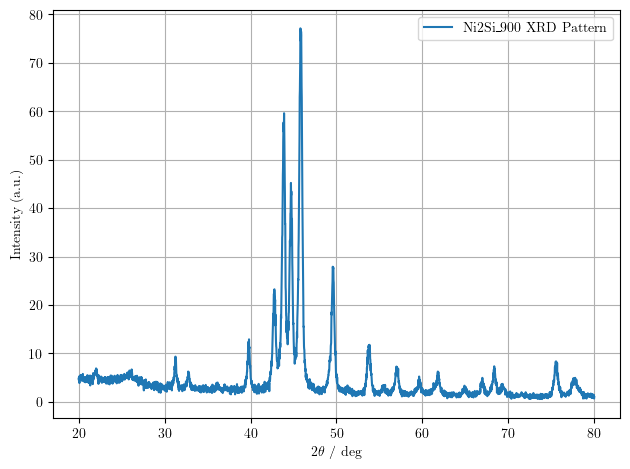

In [11]:
fig, ax = plt.subplots()

ax.plot(data['Angle'], data['Intensity'], label=f'{name} XRD Pattern')

# ax.axes.get_yaxis().set_ticklabels([])
plt.xlabel("$2\\theta$ / deg")
plt.ylabel("Intensity (a.u.)")
plt.legend()
plt.tight_layout()
plt.grid(True)
# plt.savefig(f'../Images/{name}_bessel.pdf', dpi=500)
plt.show()

## data processing
- remove background
- apply filter (Savitzky–Golay)
- normalise
- peak finding

In [8]:
# asymmetric least squares baseline correction
def baseline_als(y, lam=1e5, p=0.01, niter=10):
    L = len(y)
    D = sparse.diags([1,-2,1],[0,-1,-2], shape=(L,L-2), dtype=None)
    w = np.ones(L)
    for i in range(niter):
        W = sparse.spdiags(w,0,L,L)
        Z = W + lam * D.dot(D.transpose())
        z = spsolve(Z, w*y)
        w = p * (y > z) + (1-p) * (y < z)
    return z

### baseline correction

NameError: name 'full_processed' is not defined

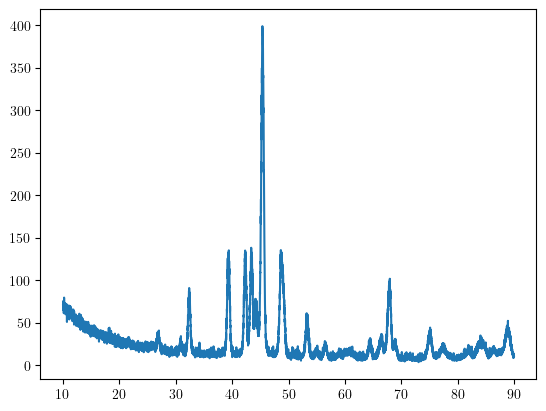

In [9]:
fig, ax = plt.subplots()
ax.plot(data['Angle'], data['Intensity'])
ax.plot(full_processed['Angle'], full_processed['baseline'])
ax.plot(full_processed['Angle'], full_processed['corrected'])
plt.grid(True)
plt.show()

In [5]:
full_processed = data.copy()

# process silicide part
full_processed['baseline'] = baseline_als(full_processed['Intensity'])
full_processed['corrected'] = full_processed['Intensity'] - full_processed['baseline']
full_processed['filtered'] = signal.savgol_filter(full_processed['corrected'], 11, 3)

# normalize everything to the silicides strongest peak
scale_factor = full_processed['filtered'].max()
full_processed['intensity_norm'] = full_processed['filtered'] / scale_factor

# find peaks in silicide and tail parts
peaks_idx, _ = signal.find_peaks(full_processed['filtered'], prominence=0.05 * full_processed['filtered'].max(), width=5)


peak_angles = full_processed.loc[peaks_idx, 'Angle']
print(peak_angles)

564     31.28
989     39.78
1138    42.76
1194    43.88
1235    44.70
1292    45.84
1480    49.60
1690    53.80
1852    57.04
2089    61.78
2420    68.40
2777    75.54
Name: Angle, dtype: float64


C:\Users\lhager\AppData\Local\Temp\ipykernel_30472\4060365311.py:9: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w*y)


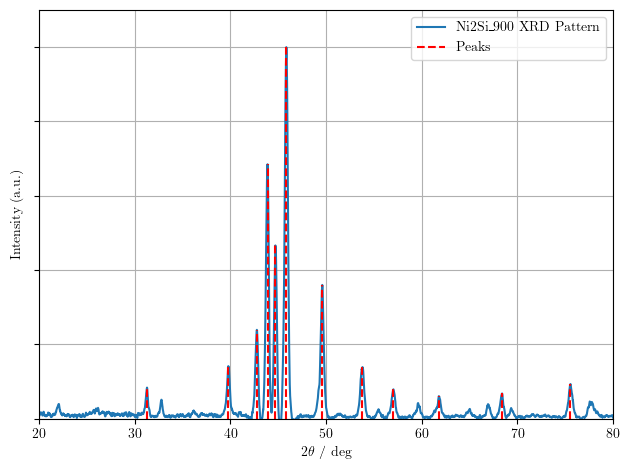

In [8]:
fig, ax = plt.subplots()

ax.plot(full_processed['Angle'], full_processed['intensity_norm'], label=f'{name} XRD Pattern')

plt.vlines(peak_angles.values, ymin=0, ymax=full_processed['intensity_norm'].iloc[peaks_idx], color='red', linestyle='--', label='Peaks')
ax.axes.get_yaxis().set_ticklabels([])
plt.xlim(20, 80)
plt.ylim(0, 1.1)
plt.gca().set_ylim(bottom=0)
plt.xlabel("$2\\theta$ / deg")
plt.ylabel("Intensity (a.u.)")
plt.legend()
plt.tight_layout()
plt.grid(True)
# plt.savefig(f'../Images/{name}_bessel.pdf', dpi=500)
plt.show()

# expermamenting with auto labeling

In [25]:
def get_clean_reference(material_id, api_key, wavelength=1.5406, intensity_threshold=5):
    with MPRester(api_key) as mpr:
        docs = mpr.materials.summary.search(material_ids=[material_id], fields=["structure"])
        if not docs:
            raise ValueError(f"No material found for {material_id}")
        structure = docs[0].structure

    calculator = XRDCalculator(wavelength=wavelength)
    pattern = calculator.get_pattern(structure)
    
    # pattern.x and pattern.y are already sorted by 2-theta
    x, y = np.array(pattern.x), np.array(pattern.y)
    
    # Normalize to 100
    y = 100 * y / np.max(y)
    
    # Filter by threshold first to remove noise/ghost peaks
    mask = y >= intensity_threshold
    return {"two_theta": x[mask], "intensity": y[mask]}

In [26]:
phase_targets = {
    "NiSi2 (Cubic)": "mp-2291",
    "NiSi (Cubic)":  "mp-1095177",
    "NiSi (Ortho)":  "mp-351",
    "Ni2Si (Ortho)": "mp-1118",
    "Ni2Si (Hex)": "mp-507",
    "Ni (Cubic)":    "mp-23",
    "Ni3Si2 (Ortho)": "mp-29667",
    "Ni31Si12 (Trigo)": "mp-27276"
}

# Fetch all reference data once
all_references = {}
for phase, m_id in phase_targets.items():
    print(f"Fetching {phase}...")
    all_references[phase] = get_clean_reference(m_id, API_KEY)

Fetching NiSi2 (Cubic)...


Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching NiSi (Cubic)...


Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching NiSi (Ortho)...


...

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching Ni3Si2 (Ortho)...


Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching Ni31Si12 (Trigo)...


Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

In [27]:
fig = go.Figure()

# 1. Plot the Experimental Data (the black line)
fig.add_trace(go.Scatter(
    x=full_processed['Angle'], 
    y=full_processed['intensity_norm'],
    mode='lines',
    name='Experimental Data',
    line=dict(color='black', width=1.5)
))

# 2. Add Reference Markers
# We use different colors/symbols for each phase fetched from the API
symbols = ['circle', 'square', 'triangle-up', 'diamond', 'star']

for i, (phase, ref) in enumerate(all_references.items()):
    # We plot these at a fixed height or relative to your data
    # Here, we plot them at y=1.05 (just above the normalized data)
    fig.add_trace(go.Scatter(
        x=ref['two_theta'],
        y=[1.05] * len(ref['two_theta']), # Align them in a row at the top
        mode='markers',
        name=phase,
        marker=dict(symbol=symbols[i % len(symbols)], size=10),
        hovertemplate=f"<b>{phase}</b><br>2θ: %{{x}}<br>Ref Intensity: %{{text}}%<extra></extra>",
        text=ref['intensity'] # Store relative intensity in hover text
    ))

# 3. Scientific Styling
fig.update_layout(
    yaxis_range=[0, 1.2],
    xaxis_range=[20, 80],
    title="Phase Identification: Nickel Silicides",
    xaxis_title="2θ (degrees)",
    yaxis_title="Intensity (Normalized)",
    template="plotly_white",
    hovermode="x unified",
    legend=dict(yanchor="top", y=0.99, xanchor="right", x=0.99)
)

fig.show()

In [28]:
final_peaks = {
'$Ni_2Si$': [32.8, 39.82, 42.78, 43.92, 45.86, 53.86], # 43.92
'$NiSi$': [31.28, 49.58, 61.78, 66.98, 75.54], 
'$Ni_3Si_2$': [44.74, 77.58],
'$Ni_{31}Si_{12}$': [57.04, 68.44]
# 'Ni': [44.5]   # 77.62
}

|Phase|material_id|shape|  |   |   |   |   |   |  |  |  |  |  |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
|$NiSi_2$|mp-2291   | Cubic | 28.68  |  47.72 | 56.63  | 69.78  | 77.12 |  |  |  |  |  |  |
|$NiSi$|mp-1095177  | Cubic | 27.77  |  34.46 | 40.00  | 44.97  | 49.54 | 61.74 | 65.48 | 69.12 | 76.15 | 79.58 |  |
|$NiSi$|mp-351      | Ortho | 31.33 | 34.87 | 35.97 | 44.53 | 46.01 | 47.57 | 52.35 | 56 | 76.29 | 79.6 |  |
|$Ni_2Si$|mp-1118   | Ortho | 27.25 | 32.85 | 39.87 | 42.83 | 44.12 | 45.94 | 49.25 | 54.07 | 68.86 | 76.14 | 78.78 |
|$Ni_2Si$|mp-507    | hex   | 32.28 | 45.72 | 46.88 | 67.57 | 77.62 |  |  |  |  |  |  |
|$Ni$   |mp-23      | Cubic | 45.15 | 52.63 | 77.65 |  |  |  |  |  |  |  |  |
|$Ni$   |mp-10257   | hex   | 42.61 | 44.45 | 48.36 | 63.27 | 77.99 |  |  |  |  |  |  |

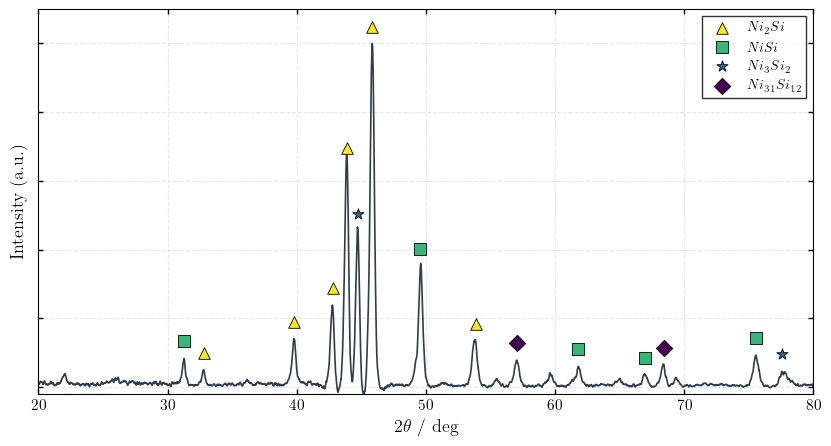

In [ ]:
marker_map = {
    '$NiSi_2$': 'o',  # Circle
    '$NiSi$': 's',   # Square
    '$Ni_2Si$': '^',  # Triangle
    '$Ni_3Si_2$': '*', # Star
    '$Ni_{31}Si_{12}$': 'D'# Diamond
}
# color_map = {
#     'NiSi2': '#00006a', 
#     'NiSi': '#8b0a74',  #8b0a74  7f007b
#     'Ni2Si': '#43a743', 
#     'Ni': '#d8c409'
# }

colors = plt.get_cmap('viridis_r')(np.linspace(0, 1, len(final_peaks)))

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(full_processed['Angle'], full_processed['intensity_norm'], color='#2c3e50', lw=1.2, zorder=2)

for lable in final_peaks:
    angles = final_peaks[lable]
    ax.scatter(angles, full_processed[full_processed['Angle'].isin(angles)]['intensity_norm'].values + 0.05, 
                marker=marker_map.get(lable, 'x'),
                color=colors[list(final_peaks.keys()).index(lable) % len(colors)],
                label=lable,
                s=70, edgecolor='black', linewidth=0.6, zorder=5)

ax.tick_params(axis='both', which='both', direction='in', 
                top=True, right=True, 
                width=1.0, labelsize=11)

ax.set_yticklabels([])
ax.set_xlim(20, 80)
ax.set_ylim(-0.02, 1.1)

ax.set_xlabel(r"$2\theta$ / deg", fontsize=13)
ax.set_ylabel(r"Intensity (a.u.)", fontsize=13)

ax.grid(True, linestyle='--', alpha=0.3, zorder=1)
ax.legend(frameon=True, edgecolor='black', fancybox=False, fontsize=10, loc='upper right')

plt.savefig(f'../Images/XRD/{name}.pdf', dpi=500)
plt.show()